# Notebook 02 — Calidad del Espacio de Embeddings y Retrieval

Analiza la calidad del espacio vectorial generado en la fase de ingesta y evalúa las métricas de recuperación (MRR, Hit@k, nDCG).

**Secciones:**
- **2.1** Carga de vectores desde pgvector
- **2.2** Reducción dimensional UMAP — visualización de clusters
- **2.3** Análisis de concentración — cohesión intra-cluster y separación inter-cluster
- **2.4** Queries de evaluación con ground truth
- **2.5** Métricas de retrieval: MRR, Hit@k, nDCG

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import psycopg2
import psycopg2.extras
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(Path("..") / ".env")

# ── DB config (Docker container en puerto 5433) ──────────────────────────────
DB_HOST     = "localhost"
DB_PORT     = 5433
DB_NAME     = "maic"
DB_USER     = "postgres"
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD", "postgres")

OPENAI_API_KEY  = os.getenv("OPENAI_API_KEY")
EMBEDDING_MODEL = "text-embedding-3-small"

oai = OpenAI(api_key=OPENAI_API_KEY)

conn = psycopg2.connect(
    host=DB_HOST, port=DB_PORT, dbname=DB_NAME,
    user=DB_USER, password=DB_PASSWORD
)
print("Conexión a pgvector OK")

Conexión a pgvector OK


## 2.1 Carga de vectores desde pgvector

In [2]:
with conn.cursor() as cur:
    cur.execute("""
        SELECT id, doc_type, source, page_no, label, content,
               embedding::text
        FROM documents
        ORDER BY doc_type, source, page_no
    """)
    rows = cur.fetchall()

df = pd.DataFrame(rows, columns=["id","doc_type","source","page_no","label","content","embedding_str"])

def parse_vec(s):
    return np.fromstring(s.strip("[]"), sep=",", dtype=np.float32)

df["vec"] = df["embedding_str"].apply(parse_vec)
embeddings = np.stack(df["vec"].values)   # (N, 1536)

print(f"Chunks cargados : {len(df)}")
print(f"Shape matriz    : {embeddings.shape}")
print()
print(df.groupby("doc_type").size().rename("chunks").to_string())

Chunks cargados : 2793
Shape matriz    : (2793, 1536)

doc_type
actas         294
contratos     161
normativa    1949
proyecto      389


## 2.2 Reducción dimensional UMAP

Proyectamos los embeddings a 2D para ver si los tipos de documento forman clusters separados en el espacio vectorial.
Un buen espacio tendrá clusters compactos y bien separados por tipo (normativa, actas, proyecto, contratos).

Reduciendo con UMAP...


c:\Users\carle\AppData\Local\pypoetry\Cache\virtualenvs\maic-m8t1-n-yrzRkq-py3.11\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reducción completada.


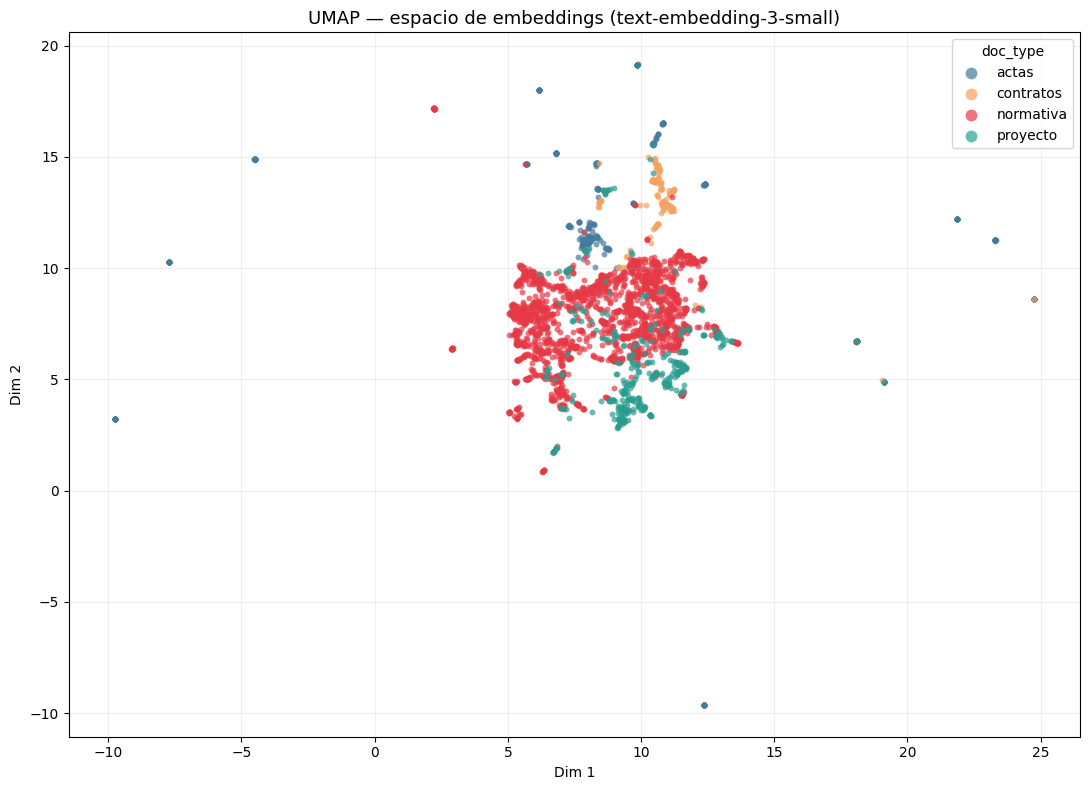

In [3]:
try:
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric="cosine", random_state=42, verbose=False)
    method_name = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, perplexity=30, metric="cosine",
                   random_state=42, n_iter=1000)
    method_name = "t-SNE (umap-learn no instalado)"

print(f"Reduciendo con {method_name}...")
coords = reducer.fit_transform(embeddings)
df["x"], df["y"] = coords[:, 0], coords[:, 1]
print("Reducción completada.")

# ── Plot ──────────────────────────────────────────────────────────────────────
PALETTE = {
    "normativa" : "#E63946",
    "actas"     : "#457B9D",
    "proyecto"  : "#2A9D8F",
    "contratos" : "#F4A261",
}
DEFAULT_COLOR = "#999999"

fig, ax = plt.subplots(figsize=(11, 8))
for doc_type, grp in df.groupby("doc_type"):
    color = PALETTE.get(doc_type, DEFAULT_COLOR)
    ax.scatter(grp["x"], grp["y"], c=color, s=18, alpha=0.7,
               linewidths=0, label=doc_type)

ax.set_title(f"{method_name} — espacio de embeddings (text-embedding-3-small)", fontsize=13)
ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
ax.legend(title="doc_type", markerscale=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2.3 Análisis de concentración del espacio

Calculamos:
- **Cohesión intra-cluster**: distancia coseno media entre chunks del mismo tipo. Cuanto menor, más compacto el cluster.
- **Separación inter-cluster**: distancia coseno media entre centroides de tipos distintos. Cuanto mayor, más separados.
- **Ratio cohesión/separación**: un ratio bajo indica buen espacio de embedding.

COHESIÓN INTRA-CLUSTER (distancia coseno media — menor = más compacto)
--------------------------------------------------
  contratos     0.6355  ██████████████████████████████████████
  normativa     0.6501  ███████████████████████████████████████
  actas         0.6565  ███████████████████████████████████████
  proyecto      0.7036  ██████████████████████████████████████████

SEPARACIÓN INTER-CLUSTER (distancia coseno entre centroides — mayor = más separado)
------------------------------------------------------------
  contratos    ↔ proyecto      0.2611  ███████████████
  contratos    ↔ normativa     0.2457  ██████████████
  actas        ↔ normativa     0.2126  ████████████
  actas        ↔ proyecto      0.1869  ███████████
  actas        ↔ contratos     0.1385  ████████
  normativa    ↔ proyecto      0.1117  ██████


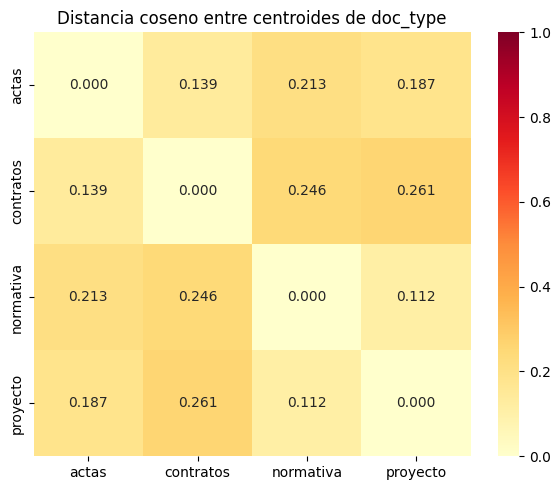

In [4]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize
import itertools

# Normalizar para operar en espacio coseno
emb_norm = normalize(embeddings, norm="l2")
doc_types = df["doc_type"].unique()

# ── Centroides por tipo ───────────────────────────────────────────────────────
centroids = {}
for dt in doc_types:
    idx = df[df["doc_type"] == dt].index
    centroids[dt] = emb_norm[idx].mean(axis=0)

# ── Cohesión intra-cluster (muestra aleatoria para eficiencia) ────────────────
rng = np.random.default_rng(42)
SAMPLE = 300

intra = {}
for dt in doc_types:
    idx = df[df["doc_type"] == dt].index.tolist()
    sample = rng.choice(idx, size=min(SAMPLE, len(idx)), replace=False)
    vecs = emb_norm[sample]
    dists = cosine_distances(vecs)
    # Solo triángulo superior (sin diagonal)
    upper = dists[np.triu_indices_from(dists, k=1)]
    intra[dt] = upper.mean()

# ── Separación inter-cluster (distancia entre centroides) ────────────────────
inter_pairs = {}
for dt1, dt2 in itertools.combinations(doc_types, 2):
    c1 = centroids[dt1].reshape(1, -1)
    c2 = centroids[dt2].reshape(1, -1)
    inter_pairs[(dt1, dt2)] = cosine_distances(c1, c2)[0, 0]

# ── Tabla resumen ─────────────────────────────────────────────────────────────
print("COHESIÓN INTRA-CLUSTER (distancia coseno media — menor = más compacto)")
print("-" * 50)
for dt, val in sorted(intra.items(), key=lambda x: x[1]):
    bar = "█" * int(val * 60)
    print(f"  {dt:<12}  {val:.4f}  {bar}")

print()
print("SEPARACIÓN INTER-CLUSTER (distancia coseno entre centroides — mayor = más separado)")
print("-" * 60)
for (dt1, dt2), val in sorted(inter_pairs.items(), key=lambda x: -x[1]):
    bar = "█" * int(val * 60)
    print(f"  {dt1:<12} ↔ {dt2:<12}  {val:.4f}  {bar}")

# ── Heatmap de distancias entre centroides ────────────────────────────────────
centroid_matrix = np.array([centroids[dt] for dt in doc_types])
dist_matrix = cosine_distances(centroid_matrix)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(dist_matrix, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=doc_types, yticklabels=doc_types,
            ax=ax, vmin=0, vmax=1)
ax.set_title("Distancia coseno entre centroides de doc_type")
plt.tight_layout()
plt.show()

## 2.4 Ground truth y función de búsqueda

Definimos un conjunto de evaluación con queries reales sobre los documentos de BANANO CORP.
Para cada query indicamos qué `doc_type` y qué fragmentos de `source` son relevantes.

> **Nota**: el ground truth es a nivel de `doc_type` + `source` (documento). Un chunk recuperado se considera relevante si pertenece a uno de los documentos marcados como relevantes para esa query.

In [5]:
EVAL_SET = [
    (
        "propiedades mecánicas y tecnológicas del acero estructural",
        [("normativa", "capitulo_18"), ("normativa", "capitulo_17")]
    ),
    (
        "durabilidad y protección frente a corrosión de estructuras metálicas",
        [("normativa", "capitulo_19"), ("normativa", "capitulo_25")]
    ),
    (
        "dimensionamiento y comprobación de estructuras de acero",
        [("normativa", "capitulo_20"), ("normativa", "capitulo_3")]
    ),
    (
        "control de calidad en la fabricación y ejecución de estructuras",
        [("normativa", "capitulo_24"), ("normativa", "capitulo_22"), ("normativa", "capitulo_23")]
    ),
    (
        "deconstrucción y desmontaje de estructuras de acero",
        [("normativa", "capitulo_26")]
    ),
    (
        "acuerdos y decisiones tomadas en las reuniones de obra",
        [("actas", "Acta_01"), ("actas", "Acta_02"), ("actas", "Acta_03"),
         ("actas", "Acta_04"), ("actas", "Acta_05")]
    ),
    (
        "condiciones económicas y plazos del contrato de obra",
        [("contratos", "Contrato")]
    ),
    (
        "planos y memoria del proyecto de estructura",
        [("proyecto", "TFG")]
    ),
    (
        "fabricación montaje y ejecución en obra de elementos de acero",
        [("normativa", "capitulo_21"), ("normativa", "capitulo_4")]
    ),
    (
        "criterios generales para el proyecto de estructuras",
        [("normativa", "capitulo_1"), ("normativa", "capitulo_3")]
    ),
]

TOP_K = 10

def is_relevant(row, relevant_list):
    for doc_type, source_substr in relevant_list:
        if row["doc_type"] == doc_type and source_substr.lower() in row["source"].lower():
            return True
    return False

def search(query: str, top_k: int = TOP_K) -> pd.DataFrame:
    resp = oai.embeddings.create(model=EMBEDDING_MODEL, input=[query])
    qvec = resp.data[0].embedding
    vec_str = "[" + ",".join(map(str, qvec)) + "]"

    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT id, doc_type, source, page_no, label, content,
                   1 - (embedding <=> '{vec_str}'::vector) AS similarity
            FROM documents
            ORDER BY embedding <=> '{vec_str}'::vector
            LIMIT {top_k}
        """)
        rows = cur.fetchall()

    return pd.DataFrame(rows, columns=["id","doc_type","source","page_no","label","content","similarity"])

# Prueba rápida
result = search("resistencia del acero")
print("Top-3 resultados para 'resistencia del acero':")
print(result[["doc_type","source","similarity"]].head(3).to_string(index=False))

Top-3 resultados para 'resistencia del acero':
 doc_type                                                                                source  similarity
 proyecto                                                                            TFG-I-1343    0.548580
 proyecto                                                                            TFG-I-1343    0.537151
normativa capitulo_18._propiedades_tecnologicas_de_los_materiales_para_las_estructuras_de_acero    0.504711


## 2.5 Métricas de retrieval: MRR, Hit@k, nDCG

| Métrica | Qué mide | Rango |
|---------|----------|-------|
| **MRR** (Mean Reciprocal Rank) | Posición media del primer resultado relevante | 0–1, mayor es mejor |
| **Hit@k** | % de queries donde al menos 1 resultado relevante aparece en top-k | 0–1 |
| **nDCG@k** (normalized Discounted Cumulative Gain) | Calidad del ranking completo penalizando por posición | 0–1, mayor es mejor |

                                                   query   MRR  Hit@1  nDCG@1  Hit@3  nDCG@3  Hit@5  nDCG@5  Hit@10  nDCG@10
propiedades mecánicas y tecnológicas del acero estructu… 1.000      1     1.0      1   0.765      1   0.637       1    0.899
durabilidad y protección frente a corrosión de estructu… 1.000      1     1.0      1   1.000      1   1.000       1    1.000
 dimensionamiento y comprobación de estructuras de acero 1.000      1     1.0      1   0.765      1   0.805       1    0.922
control de calidad en la fabricación y ejecución de est… 1.000      1     1.0      1   0.765      1   0.805       1    0.922
     deconstrucción y desmontaje de estructuras de acero 1.000      1     1.0      1   1.000      1   1.000       1    1.000
  acuerdos y decisiones tomadas en las reuniones de obra 0.000      0     0.0      0   0.000      0   0.000       0    0.000
    condiciones económicas y plazos del contrato de obra 1.000      1     1.0      1   1.000      1   0.854       1    0.971


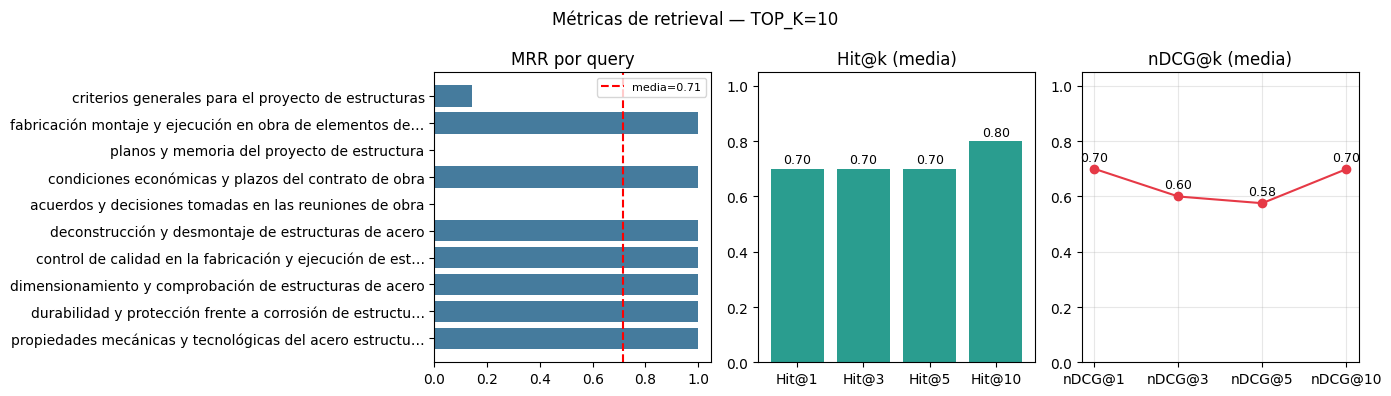

In [6]:
import math

def ndcg_at_k(relevances: list[int], k: int) -> float:
    """relevances: lista binaria (1=relevante) en orden de ranking."""
    dcg  = sum(r / math.log2(i + 2) for i, r in enumerate(relevances[:k]))
    idcg = sum(1 / math.log2(i + 2) for i in range(min(sum(relevances), k)))
    return dcg / idcg if idcg > 0 else 0.0

K_VALUES = [1, 3, 5, 10]

rows_out = []
for query, relevant_list in EVAL_SET:
    results = search(query, top_k=TOP_K)
    rels = [int(is_relevant(r, relevant_list)) for _, r in results.iterrows()]

    # MRR
    rr = 0.0
    for i, r in enumerate(rels):
        if r == 1:
            rr = 1.0 / (i + 1)
            break

    row = {"query": query[:55] + "…" if len(query) > 55 else query, "MRR": round(rr, 3)}
    for k in K_VALUES:
        row[f"Hit@{k}"]  = int(any(rels[:k]))
        row[f"nDCG@{k}"] = round(ndcg_at_k(rels, k), 3)
    rows_out.append(row)

metrics_df = pd.DataFrame(rows_out)

# ── Imprime tabla completa ────────────────────────────────────────────────────
print(metrics_df.to_string(index=False))

# ── Resumen agregado ──────────────────────────────────────────────────────────
numeric_cols = [c for c in metrics_df.columns if c != "query"]
summary = metrics_df[numeric_cols].mean().rename("MEDIA").to_frame().T
print("\n── RESUMEN (media sobre todas las queries) ──")
print(summary.round(3).to_string(index=False))

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# MRR por query
axes[0].barh(metrics_df["query"], metrics_df["MRR"], color="#457B9D")
axes[0].axvline(metrics_df["MRR"].mean(), color="red", linestyle="--", label=f"media={metrics_df['MRR'].mean():.2f}")
axes[0].set_xlim(0, 1.05)
axes[0].set_title("MRR por query")
axes[0].legend(fontsize=8)

# Hit@k agregado
hit_means = [metrics_df[f"Hit@{k}"].mean() for k in K_VALUES]
axes[1].bar([f"Hit@{k}" for k in K_VALUES], hit_means, color="#2A9D8F")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Hit@k (media)")
for i, v in enumerate(hit_means):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

# nDCG@k agregado
ndcg_means = [metrics_df[f"nDCG@{k}"].mean() for k in K_VALUES]
axes[2].plot([f"nDCG@{k}" for k in K_VALUES], ndcg_means, marker="o", color="#E63946")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("nDCG@k (media)")
axes[2].grid(True, alpha=0.3)
for i, v in enumerate(ndcg_means):
    axes[2].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle(f"Métricas de retrieval — TOP_K={TOP_K}", fontsize=12)
plt.tight_layout()
plt.show()